# This Notebook is for training the Random Forests model on the extracted features


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
feature_names = [f"feature_{i}" for i in range(2048)]
X_train = pd.read_csv("DATA/Xfeatures_train.csv")
X_train.columns = feature_names
X_train.sample(5)

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_2038,feature_2039,feature_2040,feature_2041,feature_2042,feature_2043,feature_2044,feature_2045,feature_2046,feature_2047
2050,0.000973,0.000000,0.083657,0.000000,0.200075,0.201618,0.412334,0.800275,0.215422,0.000000,...,0.018541,0.100565,0.000000,0.000000,0.021383,0.075023,0.103175,0.000000,0.000000,0.001385
522,0.003323,0.000000,1.236580,0.001019,0.026409,0.000000,0.000715,0.072992,0.032078,0.001518,...,0.070789,0.238848,0.000000,0.045671,0.266741,0.004258,0.164032,0.012105,0.000000,0.002833
1099,0.102446,0.243598,0.000000,0.006129,0.213377,0.011808,0.000000,0.011506,0.091648,0.173365,...,0.312539,0.000822,0.016121,0.208272,0.036230,0.029729,0.535845,0.000377,0.000000,0.768120
3589,0.063268,0.000000,0.000000,0.000000,0.277035,0.689013,0.627260,0.163171,0.112172,0.000208,...,0.000000,0.044465,0.261745,0.000000,0.020548,0.025685,0.000000,0.000000,0.010096,0.423414
2283,0.241322,0.191952,0.014565,0.000000,0.002757,0.553018,0.621627,0.060485,0.146207,0.037063,...,0.000000,0.382909,0.045896,0.000000,0.015547,0.155987,0.000000,0.000000,0.021965,0.573346


In [5]:
y_train = pd.Series(pd.read_csv("DATA/labels_train.csv").values.flatten())
y_train.name = "label"
y_train.sample(5)

412     1.0
3605    0.0
1059    1.0
2581    0.0
3322    0.0
Name: label, dtype: float64

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
)

In [10]:
X_test = pd.read_csv("DATA/Xfeatures_test.csv")
X_test.columns = feature_names
y_test = pd.Series(pd.read_csv("DATA/labels_test.csv").values.flatten())
y_test.name = "label"

In [11]:
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99       741
         1.0       0.97      1.00      0.99       581

    accuracy                           0.99      1322
   macro avg       0.99      0.99      0.99      1322
weighted avg       0.99      0.99      0.99      1322



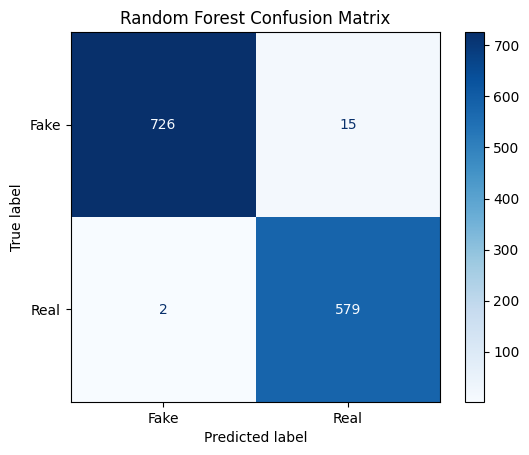

In [18]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Fake", "Real"], cmap=plt.cm.Blues
)
disp.ax_.set_title("Random Forest Confusion Matrix")
plt.show()